<a href="https://colab.research.google.com/github/jeanraposojesus-hue/Pratica-4/blob/main/Pr%C3%A1tica_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from IPython.display import Audio, display

print('--- Reprodução de Áudio: Questão 1 (DCT) ---')
print('Sinal Original:')
display(Audio(signal, rate=fs))

# Reproduzindo as compressões de 99.5%, 90% e 50%
for idx in [0, 2, 4]:
    rec_signal = results_dct[idx][0]
    print(f'Áudio DCT - Compressão {labels[idx]}')
    display(Audio(rec_signal, rate=fs))

--- Reprodução de Áudio: Questão 1 (DCT) ---
Sinal Original:


Áudio DCT - Compressão 99.5%


Áudio DCT - Compressão 90.0%


Áudio DCT - Compressão 50.0%


In [6]:
print('--- Reprodução de Áudio: Questão 2 (FFT) ---')

# Reproduzindo as compressões de 99.5%, 90% e 50% para FFT
for idx in [0, 2, 4]:
    rec_signal = results_fft[idx][0]
    print(f'Áudio FFT - Compressão {labels[idx]}')
    display(Audio(rec_signal, rate=fs))

--- Reprodução de Áudio: Questão 2 (FFT) ---
Áudio FFT - Compressão 99.5%


Áudio FFT - Compressão 90.0%


Áudio FFT - Compressão 50.0%


--- Questão 1: Compressão DCT ---
Compressão 99.5%: Coeficientes=366, MSE=26704271.66
Compressão 99.0%: Coeficientes=732, MSE=21675453.00
Compressão 90.0%: Coeficientes=7312, MSE=5161287.56
Compressão 75.0%: Coeficientes=18279, MSE=1621163.56
Compressão 50.0%: Coeficientes=36557, MSE=314388.84


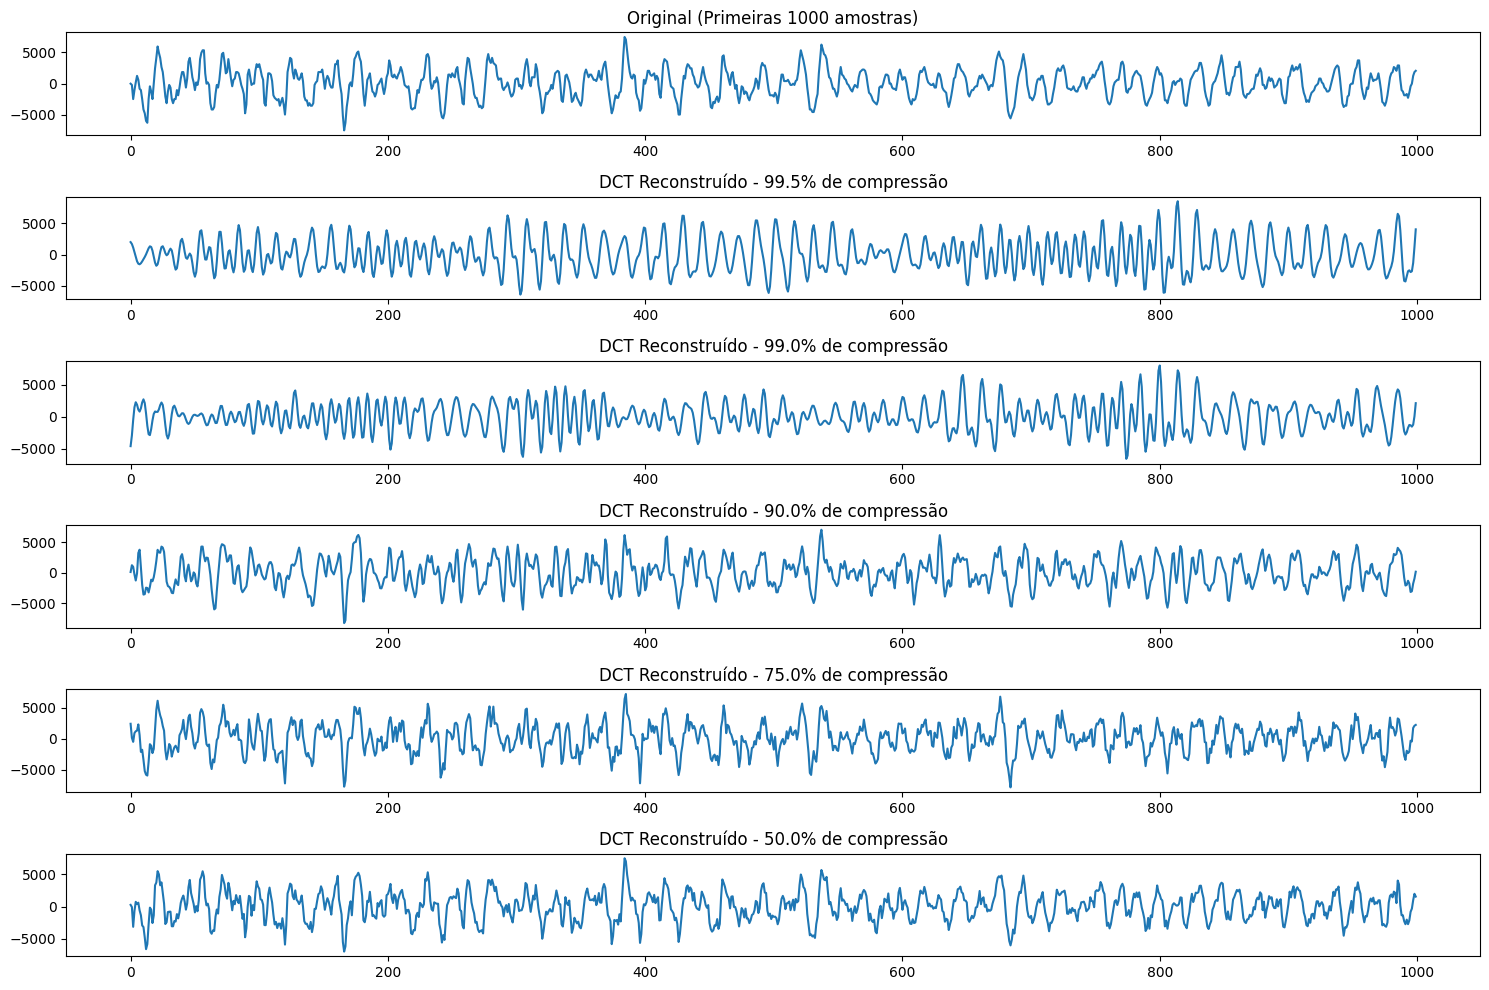

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fftpack import dct, idct, fft, ifft

# Carregando o arquivo de áudio
fs, data = wavfile.read('/content/handel.wav')
# Normalizando o sinal se necessário e garantindo que seja mono
if len(data.shape) > 1:
    data = data[:, 0]
signal = data.astype(float)

def compress_signal(signal, method='dct', keep_ratio=0.5):
    if method == 'dct':
        coeffs = dct(signal, norm='ortho')
    else:
        coeffs = fft(signal)

    # Ordenar coeficientes por magnitude e encontrar o threshold
    abs_coeffs = np.abs(coeffs)
    threshold = np.percentile(abs_coeffs, (1 - keep_ratio) * 100)

    # Zerar coeficientes abaixo do threshold
    compressed_coeffs = coeffs.copy()
    compressed_coeffs[abs_coeffs < threshold] = 0

    if method == 'dct':
        reconstructed = idct(compressed_coeffs, norm='ortho')
    else:
        reconstructed = np.real(ifft(compressed_coeffs))

    # Contagem de coeficientes não nulos
    non_zero = np.count_nonzero(compressed_coeffs)
    mse = np.mean((signal - reconstructed)**2)

    return reconstructed, non_zero, mse

ratios = [0.005, 0.01, 0.1, 0.25, 0.5] # Taxas de preservação (100% - compressão%)
labels = ['99.5%', '99.0%', '90.0%', '75.0%', '50.0%']

results_dct = []
print('--- Questão 1: Compressão DCT ---')
for r, l in zip(ratios, labels):
    rec, nz, mse = compress_signal(signal, 'dct', r)
    results_dct.append((rec, nz, mse))
    print(f'Compressão {l}: Coeficientes={nz}, MSE={mse:.2f}')

# Visualização Q1
plt.figure(figsize=(15, 10))
plt.subplot(len(ratios)+1, 1, 1)
plt.plot(signal[:1000])
plt.title('Original (Primeiras 1000 amostras)')
for i, (rec, _, _) in enumerate(results_dct):
    plt.subplot(len(ratios)+1, 1, i+2)
    plt.plot(rec[:1000])
    plt.title(f'DCT Reconstruído - {labels[i]} de compressão')
plt.tight_layout()
plt.show()

--- Questão 2: Compressão FFT ---
Compressão 99.5%: Coeficientes=366, MSE=29166876.50
Compressão 99.0%: Coeficientes=732, MSE=24288886.40
Compressão 90.0%: Coeficientes=7313, MSE=6728509.31
Compressão 75.0%: Coeficientes=18279, MSE=2317463.88
Compressão 50.0%: Coeficientes=36557, MSE=590621.52


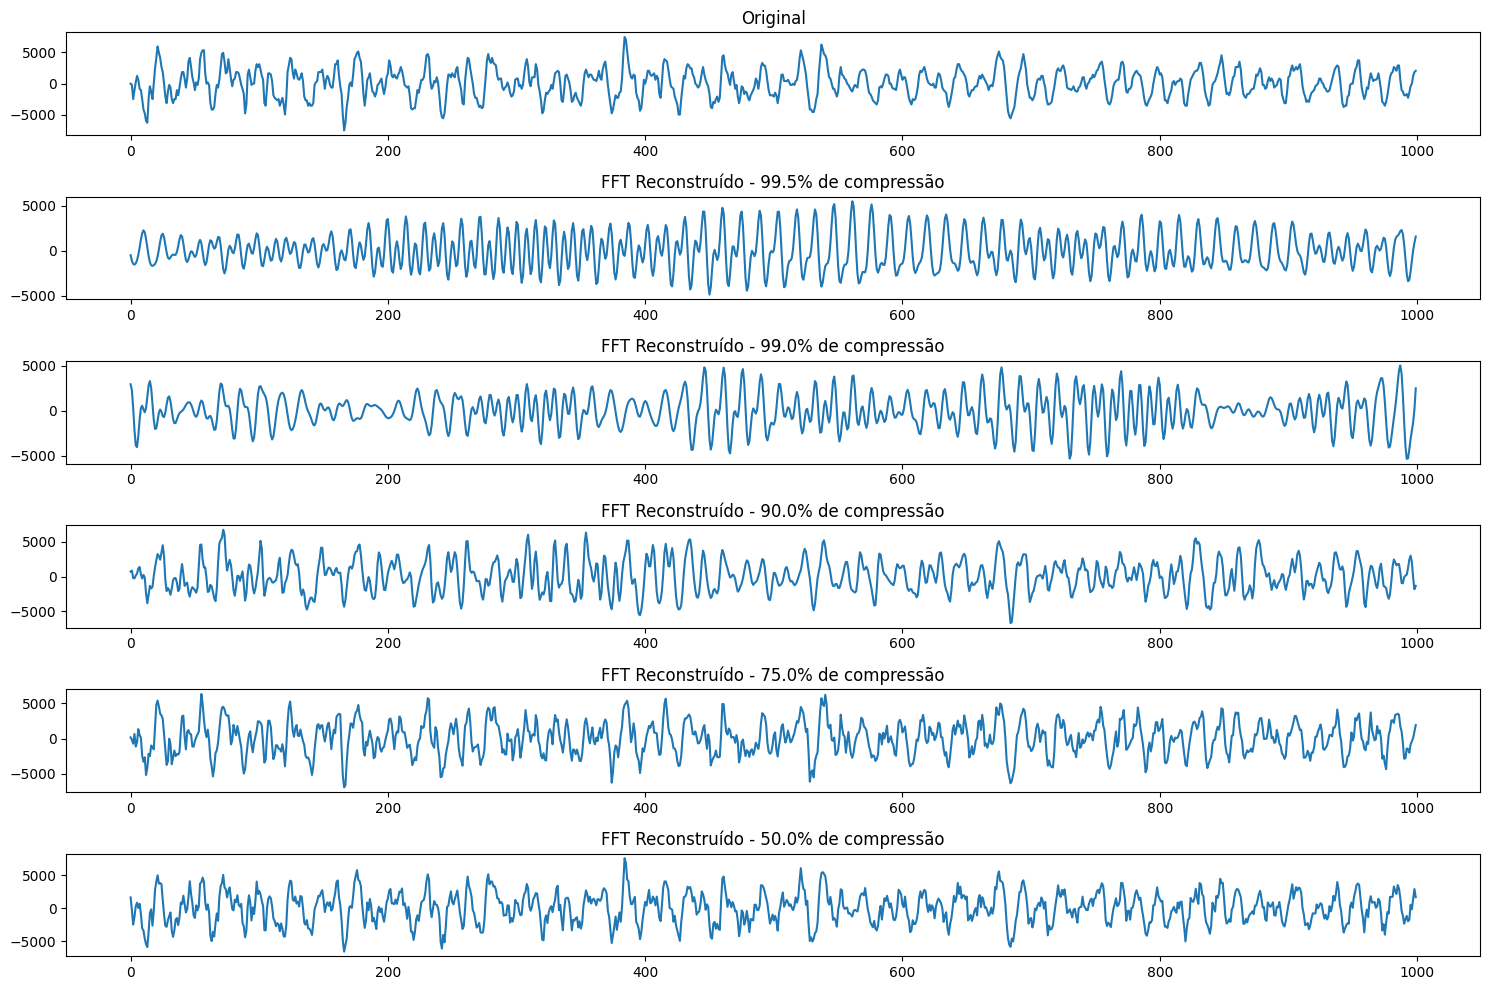

In [2]:
results_fft = []
print('--- Questão 2: Compressão FFT ---')
for r, l in zip(ratios, labels):
    rec, nz, mse = compress_signal(signal, 'fft', r)
    results_fft.append((rec, nz, mse))
    print(f'Compressão {l}: Coeficientes={nz}, MSE={mse:.2f}')

# Visualização Q2
plt.figure(figsize=(15, 10))
plt.subplot(len(ratios)+1, 1, 1)
plt.plot(signal[:1000])
plt.title('Original')
for i, (rec, _, _) in enumerate(results_fft):
    plt.subplot(len(ratios)+1, 1, i+2)
    plt.plot(rec[:1000])
    plt.title(f'FFT Reconstruído - {labels[i]} de compressão')
plt.tight_layout()
plt.show()

### Análise dos Resultados

**1(d) e 2(d) Comentários:**
À medida que a taxa de compressão aumenta (ou seja, mantemos menos coeficientes), o Erro Quadrático Médio (MSE) tende a subir. No entanto, o áudio possui muita redundância, então mesmo com 90% ou 75% de compressão, a forma de onda muitas vezes permanece reconhecível.

**2(e) Por que a DCT é mais efetiva que a DFT para compressão?**
A DCT (Discrete Cosine Transform) possui uma propriedade de **compactação de energia** superior para sinais altamente correlacionados (como áudio e imagens). Diferente da DFT (FFT), a DCT evita descontinuidades nas bordas do sinal ao espelhar o dado, o que reduz a geração de componentes de alta frequência artificiais (efeito de Gibbs nas bordas dos blocos). Isso permite que a DCT represente o sinal com menos coeficientes significativos do que a FFT.